# Analyse décisionnelle pour la gestion des stocks multi-attributs
**EMI Rabat — Devoir libre (Prof. Lamrani)**

Démarche : codification des attributs qualitatifs (Table 1) → critères agrégés (Table 2) → **TOPSIS** → **analyse ABC** → **apprentissage supervisé** sur les classes obtenues → généralisation **floue (Fuzzy TOPSIS)**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
SEED = 42
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Chargement des données et nature des variables

In [2]:
df = pd.read_csv("inventory_data.csv")
print(df.shape)
df.head()

(700, 8)


,Risk,Demand fluctuation,Average stock,Daily usage,Unit cost,Lead time,Consignment stock,Unit size
0,High,Ending,110.34,4.94,7.6445,23,Yes,Large
1,Normal,Ending,183.26,1.58,2.5091,10,No,Large
2,Normal,Stable,115.42,3.29,6.2588,17,No,Medium
3,Low,Stable,113.85,0.26,4.9519,19,Yes,Large
4,Normal,Decreasing,149.02,4.93,6.4823,24,Yes,Small


In [3]:
nature = pd.DataFrame({
    "Variable": df.columns,
    "Type pandas": [str(t) for t in df.dtypes],
    "Nature": ["Qualitative ordinale", "Qualitative ordinale", "Quantitative continue",
               "Quantitative continue", "Quantitative continue", "Quantitative discrète",
               "Qualitative nominale (binaire)", "Qualitative ordinale"],
    "Modalités / plage": [
        ", ".join(sorted(df[c].unique())) if not pd.api.types.is_numeric_dtype(df[c])
        else f"[{df[c].min():.2f} ; {df[c].max():.2f}]" for c in df.columns],
})
nature

,Variable,Type pandas,Nature,Modalités / plage
0,Risk,str,Qualitative ordinale,"High, Low, Normal"
1,Demand fluctuation,str,Qualitative ordinale,"Decreasing, Ending, Increasing, Stable, Unknown"
2,Average stock,float64,Quantitative continue,[1.07 ; 199.49]
3,Daily usage,float64,Quantitative continue,[0.02 ; 4.98]
4,Unit cost,float64,Quantitative continue,[0.10 ; 9.98]
5,Lead time,int64,Quantitative discrète,[0.00 ; 30.00]
6,Consignment stock,str,Qualitative nominale (binaire),"No, Yes"
7,Unit size,str,Qualitative ordinale,"Large, Medium, Small"


In [4]:
print("Valeurs manquantes :", int(df.isna().sum().sum()), "| doublons :", int(df.duplicated().sum()))
df.describe().T

Valeurs manquantes : 0 | doublons : 0


,count,mean,std,min,25%,50%,75%,max
Average stock,700.0,101.4380,57.5215,1.070,50.3500,104.0500,150.3975,199.490
Daily usage,700.0,2.4874,1.4566,0.020,1.2075,2.4600,3.7400,4.980
Unit cost,700.0,5.0558,2.9314,0.103,2.3419,5.1233,7.6655,9.979
Lead time,700.0,14.7643,8.9268,0.000,7.0000,15.0000,22.0000,30.000


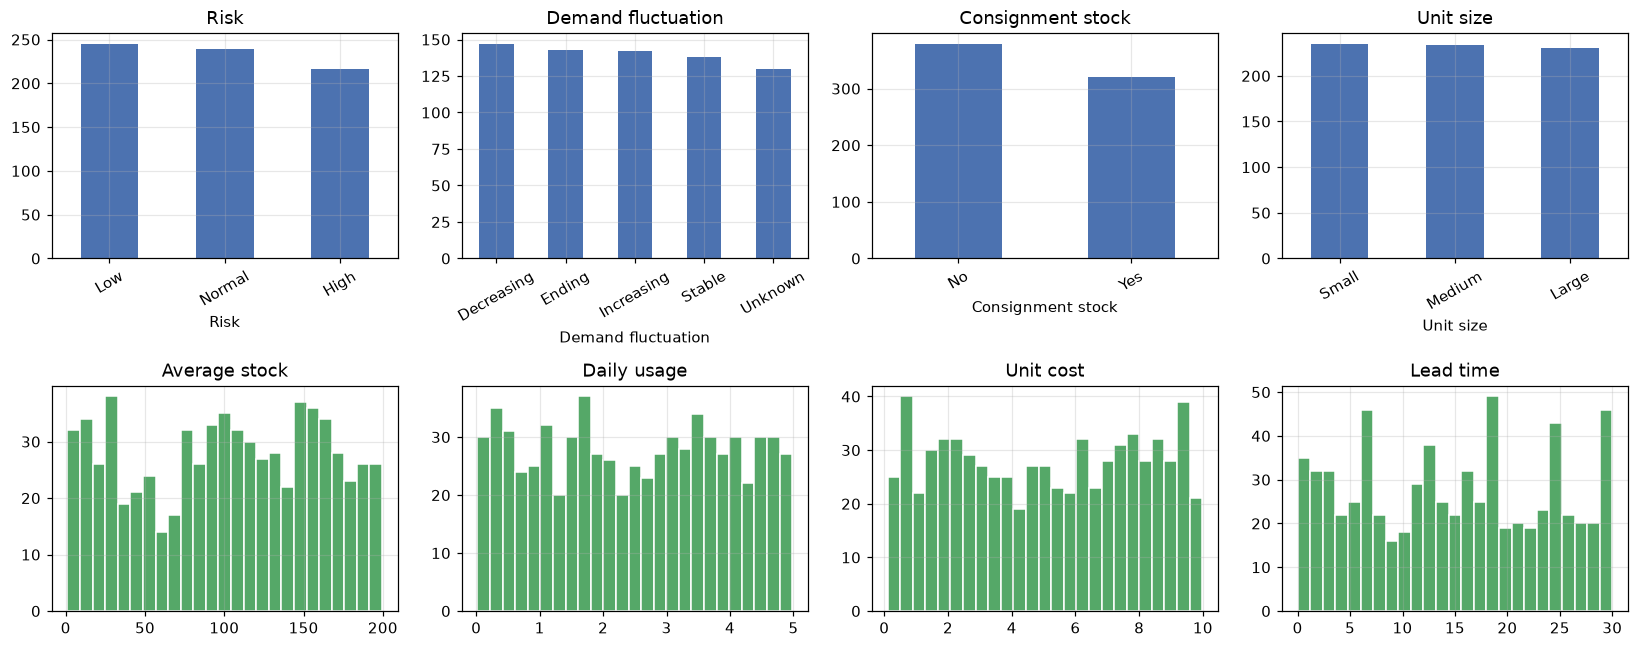

In [5]:
quali = ["Risk", "Demand fluctuation", "Consignment stock", "Unit size"]
quanti = ["Average stock", "Daily usage", "Unit cost", "Lead time"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes[0], quali):
    df[c].value_counts().plot.bar(ax=ax, color="#4C72B0"); ax.set_title(c); ax.tick_params(axis="x", rotation=30)
for ax, c in zip(axes[1], quanti):
    ax.hist(df[c], bins=25, color="#55A868", edgecolor="white"); ax.set_title(c)
plt.tight_layout(); plt.show()

**Bilan.** La base contient **700 articles** et **8 variables**, sans valeur manquante ni doublon :

- **4 variables qualitatives** : *Risk* (ordinale : Low < Normal < High), *Demand fluctuation* (ordinale : Ending < Decreasing < Unknown < Stable < Increasing), *Consignment stock* (binaire Yes/No), *Unit size* (ordinale : Small < Medium < Large) ;
- **4 variables quantitatives** : *Average stock* (unités), *Daily usage* (unités/jour), *Unit cost* (unité monétaire), *Lead time* (jours, entier).

Les modalités sont réparties de façon quasi uniforme et les variables quantitatives ont des distributions proches de l'uniforme. Leurs échelles sont très différentes (stock ≈ 0–200, usage ≈ 0–5, coût ≈ 0–10, délai 1–30), ce qui impose une normalisation avant toute agrégation.

## 2. Transformation des variables qualitatives en scores normalisés (Table 1)

Les valeurs normalisées de la Table 1 sont les valeurs assignées divisées par leur somme sur chaque attribut (ex. *High* : 8 / (8+6+3) = 0,47). On applique directement ces scores.

In [6]:
TABLE1 = {
    "Risk":               {"High": 0.47, "Normal": 0.35, "Low": 0.18},
    "Demand fluctuation": {"Increasing": 0.36, "Stable": 0.28, "Unknown": 0.20, "Decreasing": 0.16, "Ending": 0.00},
    "Consignment stock":  {"No": 0.80, "Yes": 0.20},
    "Unit size":          {"Large": 0.53, "Medium": 0.31, "Small": 0.13},
}
S = pd.DataFrame(index=df.index)
for c, m in TABLE1.items():
    S[c] = df[c].map(m)
assert S.notna().all().all()

# Variables quantitatives : normalisation min-max dans [0, 1] pour les rendre commensurables
for c in quanti:
    S[c] = (df[c] - df[c].min()) / (df[c].max() - df[c].min())
S = S[df.columns]
S.head()

,Risk,Demand fluctuation,Average stock,Daily usage,Unit cost,Lead time,Consignment stock,Unit size
0,0.47,0.00,0.5507,0.9919,0.7636,0.7667,0.2,0.53
1,0.35,0.00,0.9182,0.3145,0.2436,0.3333,0.8,0.53
2,0.35,0.28,0.5763,0.6593,0.6233,0.5667,0.8,0.31
3,0.18,0.28,0.5684,0.0484,0.4910,0.6333,0.2,0.53
4,0.35,0.16,0.7456,0.9899,0.6459,0.8000,0.2,0.13


**Pourquoi cette transformation ?**

- **Calculabilité** : TOPSIS (comme toute méthode MCDM compensatoire) repose sur des opérations arithmétiques (sommes pondérées, distances euclidiennes). Une modalité textuelle (« High », « Ending ») n'est pas exploitable directement.
- **Respect de l'ordre et de l'intensité** : contrairement à un simple codage 1-2-3 ou one-hot, les scores de la Table 1 traduisent un **jugement d'expert** sur l'écart d'importance entre modalités (ex. *Ending* vaut 0 : un article en fin de vie n'a plus d'enjeu ; *No consignment* vaut 4× *Yes* car le stock immobilise alors le capital de l'entreprise).
- **Commensurabilité** : les scores sont sans dimension et compris dans [0, 1]. Les variables quantitatives sont ramenées sur la même échelle par min-max, ce qui permet de les **combiner** entre elles (étape 3) sans qu'une variable domine par sa seule unité de mesure.
- **Homogénéité du sens** : tous les scores sont orientés « plus élevé = article plus important/plus critique », ce qui simplifie la définition de la solution idéale.

## 3. Construction des critères agrégés (Table 2)

| Critère global | Combinaison |
|---|---|
| **Criticality** | 0,78·Risk + 0,22·Demand fluctuation |
| **Demand** | 0,71·Daily usage + 0,29·Average stock |
| **Supply** | 0,75·Lead time + 0,25·Consignment |

*Unit cost* et *Unit size* ne sont pas agrégés : ils restent deux critères à part entière (notés **Cost** et **Size**) (dimension économique et dimension physique). La matrice de décision compte donc **5 critères**.

In [7]:
TABLE2 = {
    "Criticality": {"Risk": 0.78, "Demand fluctuation": 0.22},
    "Demand":      {"Daily usage": 0.71, "Average stock": 0.29},
    "Supply":      {"Lead time": 0.75, "Consignment stock": 0.25},
}
X = pd.DataFrame(index=df.index)
for g, comp in TABLE2.items():
    X[g] = sum(w * S[a] for a, w in comp.items())
X["Cost"] = df["Unit cost"]   # critère économique (valeur brute, normalisée à l'étape 4)
X["Size"] = S["Unit size"]     # critère physique (score Table 1)
CRITERIA = list(X.columns)
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Criticality,700.0,0.2992,0.0958,0.1404,0.2020,0.3170,0.3666,0.4458
Demand,700.0,0.4999,0.2250,0.0230,0.3076,0.5139,0.6853,0.9663
Supply,700.0,0.5003,0.2384,0.0500,0.3000,0.5000,0.6750,0.9500
Cost,700.0,5.0558,2.9314,0.1030,2.3419,5.1233,7.6655,9.9790
Size,700.0,0.3222,0.1635,0.1300,0.1300,0.3100,0.5300,0.5300


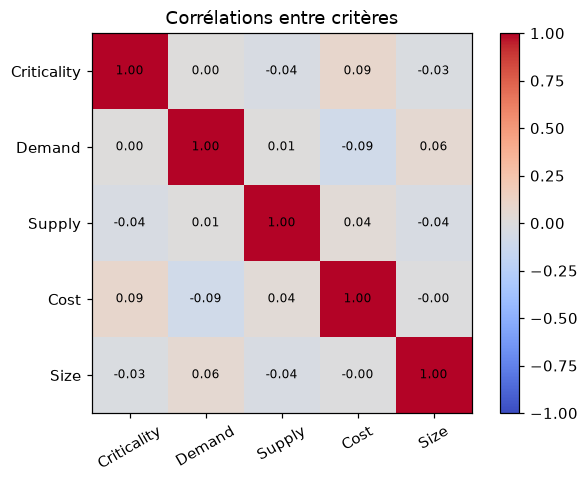

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.5))
corr = X.corr()
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(5), CRITERIA, rotation=30); ax.set_yticks(range(5), CRITERIA)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); ax.set_title("Corrélations entre critères"); ax.grid(False)
plt.tight_layout(); plt.show()

**Rôle des critères agrégés dans la décision.**

- **Réduction de dimension avec sens métier** : 8 attributs élémentaires → 5 critères interprétables, chacun associé à une question du gestionnaire : *l'article est-il critique ?* (Criticality), *est-il fortement consommé / immobilisé ?* (Demand), *est-il difficile à réapprovisionner ?* (Supply), *coûte-t-il cher ?* (Unit cost), *est-il encombrant ?* (Unit size).
- **Hiérarchisation interne** : les poids de la Table 2 expriment que, dans chaque dimension, un attribut est prépondérant (le risque pèse 78 % de la criticité, la consommation 71 % de la demande, le délai 75 % de l'approvisionnement).
- **Évite le double comptage** : des attributs relevant de la même dimension ne sont pas comptés comme des critères indépendants dans TOPSIS, ce qui équilibre le poids de chaque dimension.
- Les critères sont faiblement corrélés (matrice ci-dessus) : ils apportent des informations **complémentaires**, condition favorable pour une méthode multicritère.

## 4. Matrice de décision normalisée et pondérée — méthode TOPSIS

**Sens des critères.** On cherche à mesurer l'**importance** d'un article pour la gestion : plus un article est critique, demandé, long à réapprovisionner, cher et volumineux, plus il mérite un contrôle serré. Les 5 critères sont donc des critères **à maximiser (bénéfice)**.

**Poids des critères.** L'énoncé ne fixe pas de préférence entre les 5 critères : on retient des **poids égaux** (w = 0,2), hypothèse neutre. La robustesse de ce choix est vérifiée plus bas avec des poids objectifs (méthode de l'**entropie**).

**Étapes TOPSIS**
1. Normalisation vectorielle : $r_{ij} = x_{ij} / \sqrt{\sum_i x_{ij}^2}$
2. Pondération : $v_{ij} = w_j \, r_{ij}$
3. Solution idéale $A^+ = \max_i v_{ij}$ et anti-idéale $A^- = \min_i v_{ij}$ (critères bénéfice)
4. Distances $D_i^+ = \lVert v_i - A^+\rVert_2$, $D_i^- = \lVert v_i - A^-\rVert_2$
5. Coefficient de proximité $CC_i = D_i^- / (D_i^+ + D_i^-) \in [0,1]$

In [9]:
def topsis(M, w, benefit=None):
    M = np.asarray(M, float); w = np.asarray(w, float) / np.sum(w)
    benefit = np.ones(M.shape[1], bool) if benefit is None else np.asarray(benefit)
    R = M / np.sqrt((M ** 2).sum(axis=0))
    V = R * w
    A_pos = np.where(benefit, V.max(0), V.min(0))
    A_neg = np.where(benefit, V.min(0), V.max(0))
    d_pos = np.sqrt(((V - A_pos) ** 2).sum(1))
    d_neg = np.sqrt(((V - A_neg) ** 2).sum(1))
    return R, V, A_pos, A_neg, d_pos, d_neg, d_neg / (d_pos + d_neg)

W = np.full(len(CRITERIA), 1 / len(CRITERIA))
R, V, A_pos, A_neg, d_pos, d_neg, CC = topsis(X.values, W)

R_df = pd.DataFrame(R, columns=CRITERIA)
V_df = pd.DataFrame(V, columns=CRITERIA)
print("Matrice normalisée R (5 premiers articles)"); display(R_df.head())
print("Matrice normalisée pondérée V (5 premiers articles)"); display(V_df.head())
pd.DataFrame([A_pos, A_neg], index=["A+ (idéale)", "A- (anti-idéale)"], columns=CRITERIA)

Matrice normalisée R (5 premiers articles)


,Criticality,Demand,Supply,Cost,Size
0,0.0441,0.0596,0.0426,0.0494,0.0555
1,0.0328,0.0338,0.0307,0.0162,0.0555
2,0.0403,0.0438,0.0426,0.0405,0.0324
3,0.0243,0.0137,0.0358,0.0320,0.0555
4,0.0371,0.0634,0.0443,0.0419,0.0136


Matrice normalisée pondérée V (5 premiers articles)


,Criticality,Demand,Supply,Cost,Size
0,0.0088,0.0119,0.0085,0.0099,0.0111
1,0.0066,0.0068,0.0061,0.0032,0.0111
2,0.0081,0.0088,0.0085,0.0081,0.0065
3,0.0049,0.0027,0.0072,0.0064,0.0111
4,0.0074,0.0127,0.0089,0.0084,0.0027


,Criticality,Demand,Supply,Cost,Size
A+ (idéale),0.0107,0.0133,0.0130,0.0129,0.0111
A- (anti-idéale),0.0034,0.0003,0.0007,0.0001,0.0027


In [10]:
res = df.copy()
res[CRITERIA] = X
res["D+"], res["D-"], res["CC"] = d_pos, d_neg, CC
res[["D+", "D-", "CC"]].describe().T

,count,mean,std,min,25%,50%,75%,max
D+,700.0,0.0139,0.0031,0.0028,0.0118,0.0141,0.0163,0.0210
D-,700.0,0.0140,0.0030,0.0049,0.0120,0.0142,0.0160,0.0221
CC,700.0,0.5021,0.1103,0.1929,0.4250,0.5033,0.5724,0.8895


## 5. Classement par coefficient de proximité décroissant

In [11]:
res = res.sort_values("CC", ascending=False)
res.insert(0, "Rang", np.arange(1, len(res) + 1))
res.index.name = "Article"
cols_show = ["Rang"] + list(df.columns) + ["CC"]
print("Top 10 :"); display(res[cols_show].head(10))
print("10 derniers :"); display(res[cols_show].tail(10))

Top 10 :


,Rang,Risk,Demand fluctuation,Average stock,Daily usage,Unit cost,Lead time,Consignment stock,Unit size,CC
Article,,,,,,,,,,
546,1,High,Decreasing,128.14,4.93,8.5454,26,No,Large,0.8895
184,2,High,Increasing,161.94,3.79,9.5476,15,No,Large,0.7823
0,3,High,Ending,110.34,4.94,7.6445,23,Yes,Large,0.7712
529,4,Normal,Increasing,193.63,2.21,8.0266,30,No,Large,0.7682
171,5,High,Stable,65.47,3.15,9.5228,24,No,Large,0.7671
636,6,Normal,Increasing,159.44,4.65,6.3762,20,No,Large,0.7576
164,7,High,Ending,167.37,4.28,7.4690,26,No,Medium,0.7569
58,8,Low,Unknown,154.32,4.83,9.9511,21,No,Large,0.7547
330,9,Normal,Increasing,44.26,4.37,9.6781,25,No,Medium,0.7477


10 derniers :


,Rang,Risk,Demand fluctuation,Average stock,Daily usage,Unit cost,Lead time,Consignment stock,Unit size,CC
Article,,,,,,,,,,
528,691,Low,Unknown,97.03,1.71,0.3523,3,No,Small,0.2256
371,692,Low,Increasing,116.13,0.59,0.3154,7,Yes,Medium,0.2236
590,693,Normal,Stable,5.42,1.36,1.9816,3,Yes,Small,0.2224
409,694,Low,Increasing,7.01,0.12,1.5972,4,No,Medium,0.2202
670,695,Low,Decreasing,103.82,0.84,1.9440,1,Yes,Medium,0.2192
592,696,Low,Decreasing,54.05,1.30,0.8239,7,No,Small,0.2186
368,697,Low,Stable,153.86,0.25,2.6318,5,Yes,Small,0.2031
566,698,Low,Stable,190.77,0.19,1.4707,1,No,Small,0.2010
16,699,Normal,Decreasing,95.79,0.53,0.6185,0,No,Small,0.2004


Les articles en tête combinent un **risque élevé**, une **demande croissante ou stable**, une **forte consommation**, un **délai long**, **sans consignation**, et un **coût / volume élevés** : ce sont bien ceux dont une rupture ou un surstock coûterait le plus. À l'inverse, les derniers sont à faible risque, en fin de vie (*Ending*), peu consommés, rapidement livrés et en consignation.

## 6. Analyse ABC sur le classement TOPSIS

Le coefficient $CC$ n'est pas une grandeur monétaire additive : faire un cumul « à 80 % de la valeur » n'aurait pas de sens économique (et, les $CC$ étant concentrés autour de 0,4–0,6, la classe A contiendrait plus de 60 % des articles). On applique donc le principe de Pareto sur **le rang** : les seuils retenus sont ceux de l'énoncé, **20 % / 30 % / 50 % des articles**.

- **A** : rangs 1 à 140 (20 %)
- **B** : rangs 141 à 350 (30 %)
- **C** : rangs 351 à 700 (50 %)

In [12]:
n = len(res)
nA, nB = int(round(0.20 * n)), int(round(0.30 * n))
res["Classe"] = np.where(res["Rang"] <= nA, "A", np.where(res["Rang"] <= nA + nB, "B", "C"))
seuil_A = res.loc[res["Rang"] == nA, "CC"].item()
seuil_B = res.loc[res["Rang"] == nA + nB, "CC"].item()
print(f"Seuil A : CC >= {seuil_A:.4f}   |   Seuil B : {seuil_B:.4f} <= CC < {seuil_A:.4f}   |   C : CC < {seuil_B:.4f}")

# Part de la « valeur de consommation » annuelle (critère ABC classique) captée par chaque classe
res["Valeur annuelle"] = res["Daily usage"] * 365 * res["Unit cost"]
synth = res.groupby("Classe").agg(Nb=("CC", "size"), CC_min=("CC", "min"), CC_max=("CC", "max"),
                                  CC_moy=("CC", "mean"), Valeur=("Valeur annuelle", "sum"))
synth["% articles"] = 100 * synth["Nb"] / n
synth["% valeur annuelle"] = 100 * synth["Valeur"] / synth["Valeur"].sum()
synth.drop(columns="Valeur")

Seuil A : CC >= 0.6004   |   Seuil B : 0.5033 <= CC < 0.6004   |   C : CC < 0.5033


,Nb,CC_min,CC_max,CC_moy,% articles,% valeur annuelle
Classe,,,,,,
A,140,0.6004,0.8895,0.6581,20.0,41.4775
B,210,0.5033,0.5992,0.5437,30.0,35.1799
C,350,0.1929,0.5033,0.4147,50.0,23.3426


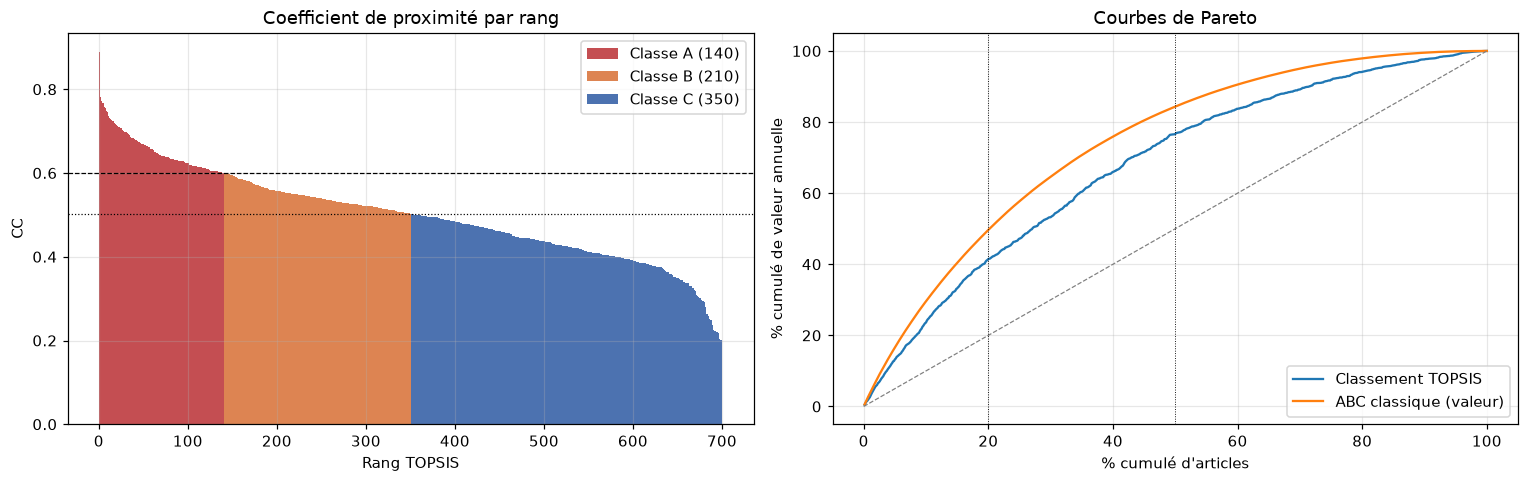

In [13]:
colors = {"A": "#C44E52", "B": "#DD8452", "C": "#4C72B0"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
for k, g in res.groupby("Classe"):
    ax.bar(g["Rang"], g["CC"], width=1.0, color=colors[k], label=f"Classe {k} ({len(g)})")
ax.axhline(seuil_A, ls="--", c="k", lw=0.8); ax.axhline(seuil_B, ls=":", c="k", lw=0.8)
ax.set_xlabel("Rang TOPSIS"); ax.set_ylabel("CC"); ax.set_title("Coefficient de proximité par rang"); ax.legend()

ax = axes[1]
cum_items = res["Rang"] / n * 100
cum_val = res["Valeur annuelle"].cumsum() / res["Valeur annuelle"].sum() * 100
ax.plot(cum_items, cum_val, label="Classement TOPSIS")
classic = res["Valeur annuelle"].sort_values(ascending=False)
ax.plot(np.arange(1, n + 1) / n * 100, classic.cumsum() / classic.sum() * 100, label="ABC classique (valeur)")
ax.plot([0, 100], [0, 100], c="grey", lw=0.8, ls="--")
for x in (20, 50): ax.axvline(x, c="k", lw=0.6, ls=":")
ax.set_xlabel("% cumulé d'articles"); ax.set_ylabel("% cumulé de valeur annuelle")
ax.set_title("Courbes de Pareto"); ax.legend()
plt.tight_layout(); plt.show()

In [14]:
# Profil moyen des classes
prof = res.groupby("Classe")[CRITERIA + ["CC"]].mean()
display(prof)
for c in quali:
    display(pd.crosstab(res["Classe"], res[c], normalize="index").mul(100).round(1).add_prefix(f"{c}: "))

,Criticality,Demand,Supply,Cost,Size,CC
Classe,,,,,,
A,0.3359,0.6584,0.6552,7.3523,0.4096,0.6581
B,0.2974,0.5373,0.5573,5.9839,0.3356,0.5437
C,0.2857,0.4140,0.4042,3.5802,0.2791,0.4147


Risk,Risk: High,Risk: Low,Risk: Normal
Classe,,,
A,43.6,17.1,39.3
B,29.0,34.3,36.7
C,26.9,42.6,30.6


Demand fluctuation,Demand fluctuation: Decreasing,Demand fluctuation: Ending,Demand fluctuation: Increasing,Demand fluctuation: Stable,Demand fluctuation: Unknown
Classe,,,,,
A,21.4,18.6,20.7,20.7,18.6
B,22.4,21.4,17.6,21.9,16.7
C,20.0,20.6,21.7,18.0,19.7


Consignment stock,Consignment stock: No,Consignment stock: Yes
Classe,,
A,64.3,35.7
B,57.6,42.4
C,48.0,52.0


Unit size,Unit size: Large,Unit size: Medium,Unit size: Small
Classe,,,
A,52.9,37.9,9.3
B,36.2,33.8,30.0
C,23.1,31.4,45.4


**Comparaison avec l'ABC classique.** La courbe de Pareto montre que la valeur monétaire seule (consommation × coût) produit une distribution peu concentrée sur ces données (les 20 % d'articles les plus valorisés ne représentent qu'environ 50 % de la valeur, loin du 80/20 théorique — la classe A TOPSIS en capte encore 41 %). Le classement multicritère ne cherche pas à maximiser cette part : il intègre le risque, la tendance de la demande, le délai et la consignation, et peut donc placer en A un article bon marché mais critique et long à réapprovisionner — exactement ce qu'une analyse mono-critère ignore.

## 7. Ajout de la variable *Classe* et justification des seuils

In [15]:
df_classe = df.copy()
df_classe["Score TOPSIS"] = res["CC"].reindex(df.index)
df_classe["Rang"] = res["Rang"].reindex(df.index)
df_classe["Classe"] = res["Classe"].reindex(df.index)
df_classe.to_csv("inventory_data_classe.csv", index=False)
print(df_classe["Classe"].value_counts().sort_index())
df_classe.head(10)

Classe
A    140
B    210
C    350
Name: count, dtype: int64


,Risk,Demand fluctuation,Average stock,Daily usage,Unit cost,Lead time,Consignment stock,Unit size,Score TOPSIS,Rang,Classe
0,High,Ending,110.34,4.94,7.6445,23,Yes,Large,0.7712,3,A
1,Normal,Ending,183.26,1.58,2.5091,10,No,Large,0.4727,426,C
2,Normal,Stable,115.42,3.29,6.2588,17,No,Medium,0.6137,115,A
3,Low,Stable,113.85,0.26,4.9519,19,Yes,Large,0.4586,455,C
4,Normal,Decreasing,149.02,4.93,6.4823,24,Yes,Small,0.6155,111,A
5,Low,Unknown,117.18,0.96,3.7550,6,No,Small,0.2920,680,C
6,Normal,Ending,24.11,1.82,1.4825,4,No,Large,0.3745,632,C
7,High,Unknown,87.37,4.41,9.1250,24,Yes,Medium,0.7321,12,A
8,Normal,Decreasing,179.40,3.65,0.5708,18,Yes,Small,0.4360,504,C
9,Low,Stable,163.53,4.97,2.2241,12,Yes,Medium,0.4879,389,C


La base enrichie est exportée dans **`inventory_data_classe.csv`** (colonnes ajoutées : *Score TOPSIS*, *Rang*, *Classe*).

**Justification des seuils 20 / 30 / 50 %**

1. **Cohérence avec le principe de Pareto** rappelé dans l'énoncé : A ≈ 20 %, B ≈ 30 %, C ≈ 50 % des articles.
2. **Score non monétaire** : le CC TOPSIS mesure une proximité relative à l'idéal, pas une valeur additive. Un seuil sur la part cumulée du score serait arbitraire ; un seuil sur les **quantiles du rang** est la transposition directe de l'ABC.
3. **Capacité de gestion** : limiter la classe A à 140 articles garde un effectif compatible avec un suivi rigoureux (prévisions fines, inventaires tournants fréquents, stock de sécurité élevé).
4. **Lecture en score** : cela revient à $CC \ge$ seuil_A pour A et $CC \ge$ seuil_B pour B (valeurs calculées à l'étape 6), seuils réutilisables pour classer de nouveaux articles.
5. **Discrimination effective** : les profils moyens des classes sont nettement séparés (proportions de risque élevé, de demande croissante, de stock non consigné…), ce qui confirme que la partition a un sens opérationnel.

### Analyse de sensibilité : poids d'entropie

Pour vérifier que le choix des poids égaux ne conditionne pas les résultats, on recalcule TOPSIS avec des poids **objectifs** issus de l'entropie de Shannon (un critère est d'autant plus pondéré que ses valeurs sont dispersées entre articles).

In [16]:
P = X / X.sum()
E = -(P * np.log(P.replace(0, np.nan))).sum() / np.log(n)
W_ent = (1 - E) / (1 - E).sum()
display(pd.DataFrame({"Poids égaux": W, "Poids entropie": W_ent.values}, index=CRITERIA))

CC_ent = topsis(X.values, W_ent.values)[-1]
rang_ent = pd.Series(CC_ent, index=df.index).rank(ascending=False, method="first")
classe_ent = np.where(rang_ent <= nA, "A", np.where(rang_ent <= nA + nB, "B", "C"))
rho = spearmanr(df_classe["Score TOPSIS"], CC_ent)[0]
print(f"Corrélation de Spearman des scores : {rho:.4f}")
print(f"Concordance des classes ABC : {100 * np.mean(classe_ent == df_classe['Classe']):.1f} %")
pd.crosstab(df_classe["Classe"], classe_ent, rownames=["Poids égaux"], colnames=["Poids entropie"])

,Poids égaux,Poids entropie
Criticality,0.2,0.0867
Demand,0.2,0.1794
Supply,0.2,0.2019
Cost,0.2,0.3130
Size,0.2,0.2191


Corrélation de Spearman des scores : 0.8891
Concordance des classes ABC : 73.7 %


Poids entropie,A,B,C
Poids égaux,,,
A,105,35,0
B,35,118,57
C,0,57,293


**Lecture.** L'entropie réduit fortement le poids de *Criticality* (≈ 0,09), dont les valeurs sont peu dispersées, et augmente celui de *Cost* (≈ 0,31). Malgré ce changement important, les scores restent très corrélés (Spearman ≈ 0,89) et **aucun article ne passe de A à C ou inversement** ; environ 74 % des articles gardent leur classe, les changements portant sur les frontières A/B et B/C.

Conclusion : la structure du classement est robuste, mais l'affectation des articles proches des seuils dépend des poids. Ceux-ci devraient idéalement être fixés par les gestionnaires (AHP, jugements d'experts). L'approche floue (question 10) traite explicitement cette zone d'ambiguïté. On conserve les **poids égaux** pour la suite : l'entropie mesure la dispersion statistique, pas l'importance métier (elle minimiserait le risque opérationnel, ce qui n'est pas souhaitable).

## 8. Apprentissage supervisé : classification automatique A / B / C

**Objectif** : apprendre à prédire la classe d'un **nouvel article** directement à partir de ses 8 attributs bruts, sans refaire tout le calcul TOPSIS (qui dépend de l'ensemble du portefeuille via la normalisation et les solutions idéales).

**Choix méthodologiques**
- **Variables explicatives** : les 8 attributs d'origine. Les qualitatives ordinales sont codées par les scores de la Table 1 (ordre et intensité conservés), les quantitatives sont standardisées. On n'utilise **pas** le score TOPSIS ni les critères agrégés comme entrées (sinon fuite d'information : la cible serait déduite trivialement).
- **Cible** : *Classe* (A, B, C) — classes déséquilibrées (20/30/50 %) → découpage **stratifié**.
- **Protocole** : jeu d'apprentissage 70 % / test 30 %, validation croisée stratifiée à 5 plis sur l'apprentissage, hyperparamètres réglés par `GridSearchCV` sur le F1-macro.
- **Modèles comparés** : régression logistique multinomiale, k plus proches voisins, arbre de décision, forêt aléatoire, gradient boosting, SVM (noyau RBF), réseau de neurones (MLP), Naïve Bayes gaussien.

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score,
                             roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

features = pd.DataFrame(index=df.index)
for c in df.columns:
    features[c] = S[c] if c in TABLE1 else df[c]
y = df_classe["Classe"]

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.30, stratify=y, random_state=SEED)
print("Apprentissage :", X_train.shape, y_train.value_counts().sort_index().to_dict())
print("Test          :", X_test.shape, y_test.value_counts().sort_index().to_dict())

Apprentissage : (490, 8) {'A': 98, 'B': 147, 'C': 245}
Test          : (210, 8) {'A': 42, 'B': 63, 'C': 105}


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
def pipe(model): return Pipeline([("scaler", StandardScaler()), ("clf", model)])

candidates = {
    "Régression logistique": (pipe(LogisticRegression(max_iter=5000)), {"clf__C": [0.1, 1, 10, 100]}),
    "k-NN":                  (pipe(KNeighborsClassifier()), {"clf__n_neighbors": [3, 5, 9, 15, 25], "clf__weights": ["uniform", "distance"]}),
    "Arbre de décision":     (pipe(DecisionTreeClassifier(random_state=SEED)), {"clf__max_depth": [4, 6, 8, 12, None], "clf__min_samples_leaf": [1, 5, 10]}),
    "Forêt aléatoire":       (pipe(RandomForestClassifier(random_state=SEED)), {"clf__n_estimators": [300], "clf__max_depth": [None, 10], "clf__min_samples_leaf": [1, 3]}),
    "Gradient boosting":     (pipe(GradientBoostingClassifier(random_state=SEED)), {"clf__n_estimators": [200, 400], "clf__learning_rate": [0.05, 0.1], "clf__max_depth": [2, 3]}),
    "SVM (RBF)":             (pipe(SVC(probability=True, random_state=SEED)), {"clf__C": [1, 10, 100], "clf__gamma": ["scale", 0.05, 0.01]}),
    "MLP":                   (pipe(MLPClassifier(max_iter=3000, random_state=SEED)), {"clf__hidden_layer_sizes": [(32,), (64, 32)], "clf__alpha": [1e-4, 1e-2, 1e-1]}),
    "Naïve Bayes":           (pipe(GaussianNB()), {}),
}

best_models, rows = {}, []
for name, (model, grid) in candidates.items():
    gs = GridSearchCV(model, grid, scoring="f1_macro", cv=cv, n_jobs=-1).fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    cvr = cross_validate(gs.best_estimator_, X_train, y_train, cv=cv, scoring=["accuracy", "f1_macro"], n_jobs=-1)
    rows.append({"Modèle": name,
                 "Meilleurs hyperparamètres": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()},
                 "CV accuracy": f"{cvr['test_accuracy'].mean():.3f} ± {cvr['test_accuracy'].std():.3f}",
                 "CV F1-macro": f"{cvr['test_f1_macro'].mean():.3f} ± {cvr['test_f1_macro'].std():.3f}"})
pd.set_option("display.max_colwidth", 90)
pd.DataFrame(rows).set_index("Modèle")

,Meilleurs hyperparamètres,CV accuracy,CV F1-macro
Modèle,,,
Régression logistique,{'C': 10},0.969 ± 0.009,0.963 ± 0.008
k-NN,"{'n_neighbors': 15, 'weights': 'distance'}",0.804 ± 0.031,0.772 ± 0.033
Arbre de décision,"{'max_depth': 4, 'min_samples_leaf': 5}",0.727 ± 0.043,0.708 ± 0.054
Forêt aléatoire,"{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}",0.822 ± 0.026,0.795 ± 0.023
Gradient boosting,"{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}",0.835 ± 0.032,0.806 ± 0.040
SVM (RBF),"{'C': 100, 'gamma': 0.01}",0.939 ± 0.017,0.935 ± 0.018
MLP,"{'alpha': 0.1, 'hidden_layer_sizes': (32,)}",0.955 ± 0.018,0.948 ± 0.022
Naïve Bayes,{},0.820 ± 0.034,0.790 ± 0.027


## 9. Évaluation et comparaison des performances (jeu de test)

Indicateurs retenus :
- **Accuracy** : taux global de bonnes classifications ;
- **Précision, rappel, F1 en moyenne macro** : chaque classe pèse autant, ce qui évite qu'un modèle performant seulement sur la classe C (50 % des articles) paraisse bon ;
- **Rappel de la classe A** : indicateur métier — un article A classé B/C est sous-surveillé, donc exposé au risque de rupture ;
- **Kappa de Cohen** : accord corrigé du hasard ;
- **AUC ROC (one-vs-rest, macro)** : qualité du classement probabiliste ;
- **Matrices de confusion**.

In [19]:
labels = ["A", "B", "C"]
perf = []
for name, m in best_models.items():
    yp = m.predict(X_test)
    proba = m.predict_proba(X_test)
    perf.append({"Modèle": name,
                 "Accuracy": accuracy_score(y_test, yp),
                 "Précision macro": precision_score(y_test, yp, average="macro"),
                 "Rappel macro": recall_score(y_test, yp, average="macro"),
                 "F1 macro": f1_score(y_test, yp, average="macro"),
                 "Rappel A": recall_score(y_test, yp, labels=["A"], average=None)[0],
                 "Kappa": cohen_kappa_score(y_test, yp),
                 "AUC OvR": roc_auc_score(y_test, proba, multi_class="ovr", labels=labels)})
perf = pd.DataFrame(perf).set_index("Modèle").sort_values("F1 macro", ascending=False)
perf.style.format("{:.3f}").background_gradient(cmap="Greens")

,Accuracy,Précision macro,Rappel macro,F1 macro,Rappel A,Kappa,AUC OvR
Modèle,,,,,,,
MLP,0.938,0.925,0.923,0.923,0.929,0.900,0.992
SVM (RBF),0.933,0.921,0.922,0.921,0.929,0.892,0.992
Régression logistique,0.929,0.903,0.905,0.904,0.857,0.885,0.989
Gradient boosting,0.829,0.814,0.810,0.812,0.833,0.722,0.941
Forêt aléatoire,0.805,0.810,0.771,0.787,0.738,0.678,0.929
k-NN,0.800,0.792,0.758,0.771,0.667,0.672,0.921
Naïve Bayes,0.800,0.811,0.739,0.760,0.571,0.666,0.953
Arbre de décision,0.748,0.730,0.717,0.723,0.690,0.590,0.861


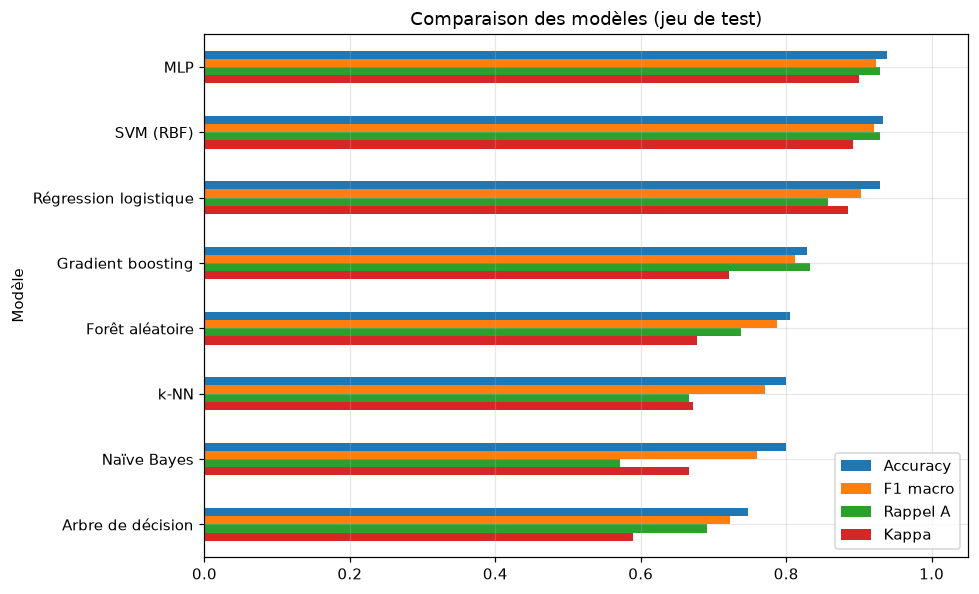

In [20]:
ax = perf[["Accuracy", "F1 macro", "Rappel A", "Kappa"]].plot.barh(figsize=(9, 5.5))
ax.invert_yaxis(); ax.set_xlim(0, 1.05); ax.set_title("Comparaison des modèles (jeu de test)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

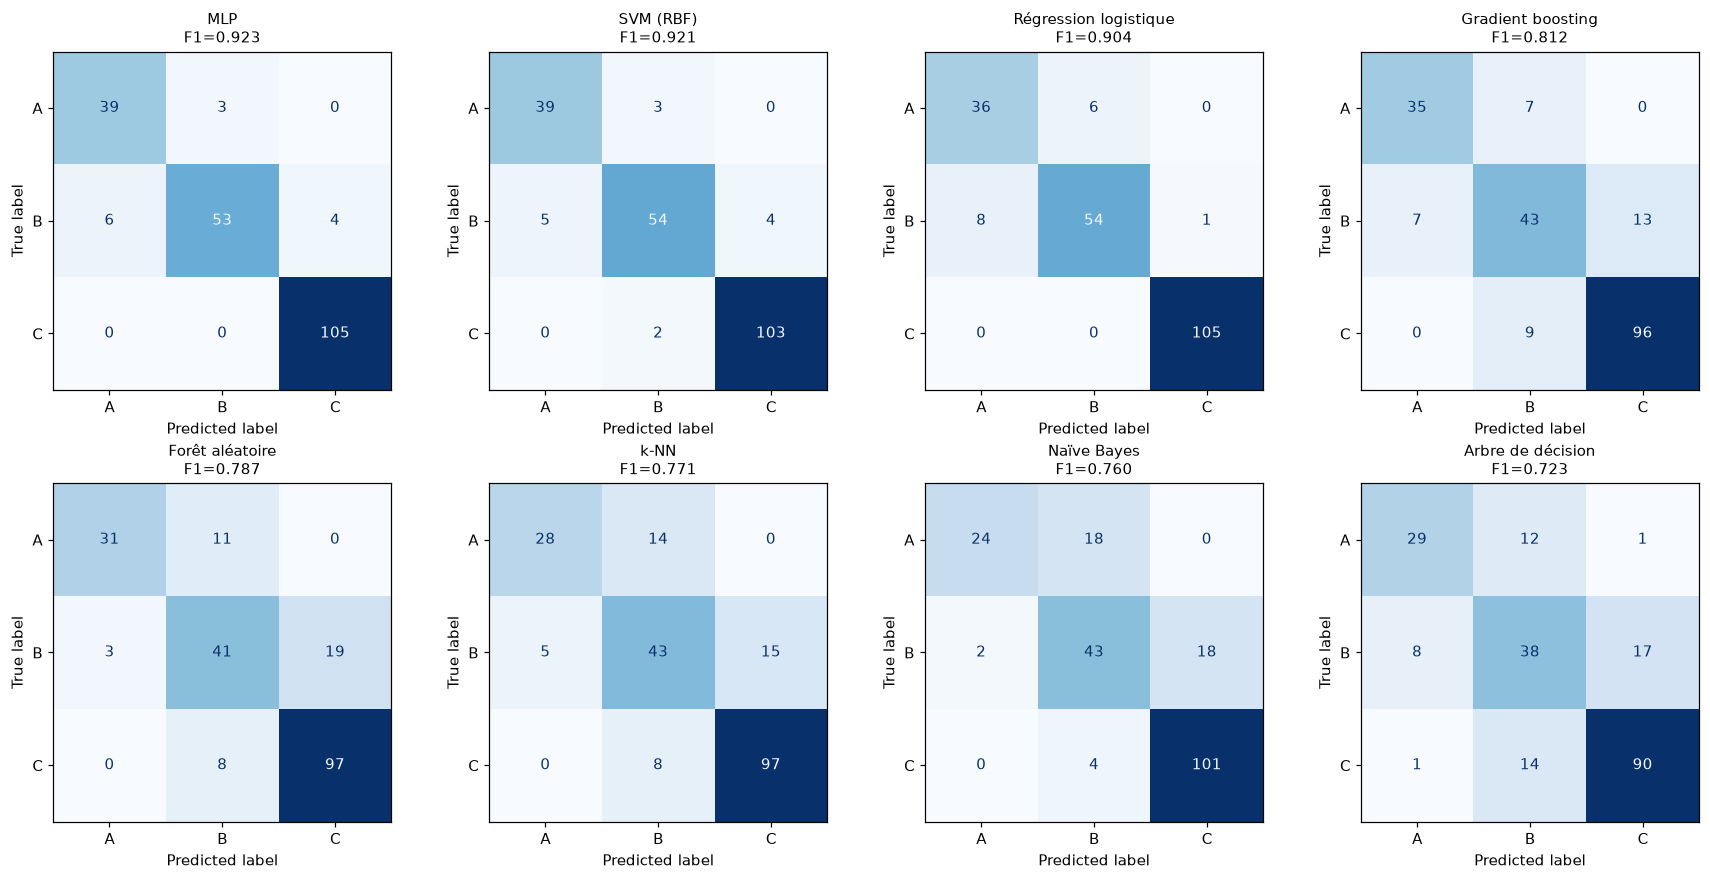

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, name in zip(axes.ravel(), perf.index):
    ConfusionMatrixDisplay(confusion_matrix(y_test, best_models[name].predict(X_test), labels=labels),
                           display_labels=labels).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nF1={perf.loc[name, 'F1 macro']:.3f}", fontsize=10); ax.grid(False)
plt.tight_layout(); plt.show()

In [22]:
best_name = perf.index[0]
print("Meilleur modèle :", best_name)
print(classification_report(y_test, best_models[best_name].predict(X_test), digits=3))

Meilleur modèle : MLP
              precision    recall  f1-score   support

           A      0.867     0.929     0.897        42
           B      0.946     0.841     0.891        63
           C      0.963     1.000     0.981       105

    accuracy                          0.938       210
   macro avg      0.925     0.923     0.923       210
weighted avg      0.939     0.938     0.937       210



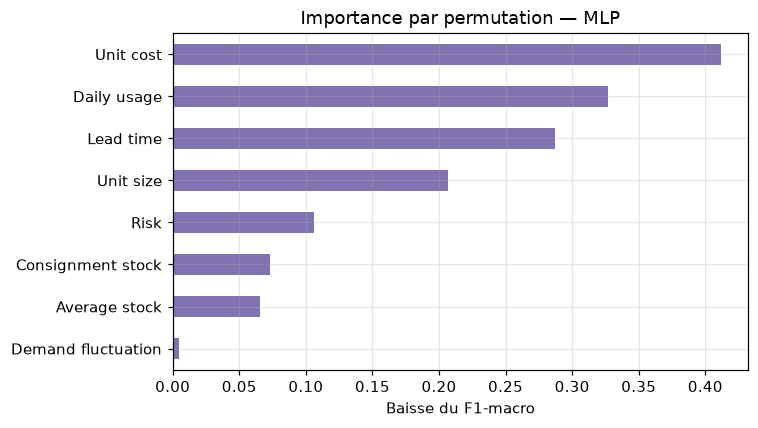

In [23]:
# Importance des variables (permutation) pour le meilleur modèle
from sklearn.inspection import permutation_importance
pi = permutation_importance(best_models[best_name], X_test, y_test, scoring="f1_macro", n_repeats=20, random_state=SEED)
imp = pd.Series(pi.importances_mean, index=features.columns).sort_values()
ax = imp.plot.barh(figsize=(7, 4), color="#8172B2")
ax.set_title(f"Importance par permutation — {best_name}"); ax.set_xlabel("Baisse du F1-macro")
plt.tight_layout(); plt.show()

**Analyse.**

- **Trois modèles se détachent nettement** : MLP, SVM (RBF) et régression logistique (accuracy ≈ 93–94 %, F1-macro ≈ 0,90–0,92, kappa ≈ 0,89–0,90, AUC ≈ 0,99). Les classes sont une fonction déterministe des attributs, et le score TOPSIS est presque monotone et quasi additif en chaque variable : les frontières A/B et B/C sont donc proches d'**hyperplans obliques**. Même la régression logistique, modèle linéaire, les capture très bien (c'est d'ailleurs le meilleur modèle en validation croisée, F1 ≈ 0,96).
- Les **modèles à base d'arbres** (gradient boosting, forêt aléatoire, arbre seul) découpent l'espace en hyper-rectangles parallèles aux axes et approximent mal une frontière oblique combinant 8 variables : F1 entre 0,72 et 0,81. L'**arbre de décision** est le moins bon (F1 ≈ 0,72) et c'est le seul à confondre un article A avec un article C.
- **k-NN** souffre de la distance euclidienne non pondérée (toutes les variables comptent autant, contrairement à TOPSIS). **Naïve Bayes** suppose des attributs indépendants et gaussiens, hypothèses non vérifiées ; il a le plus mauvais rappel de la classe A (≈ 0,57), donc le plus risqué en pratique.
- Pour tous les modèles hors arbre seul, les erreurs se situent **uniquement entre classes adjacentes** (A↔B, B↔C). Elles concernent des articles dont le score est proche d'un seuil, ce qui motive l'approche floue (question 10).
- **Importance des variables** : *Unit cost*, *Daily usage*, *Lead time* et *Unit size* dominent, puis *Risk* et *Consignment stock* ; *Average stock* et surtout *Demand fluctuation* pèsent peu. C'est cohérent avec la construction : *Cost* et *Size* sont des critères à part entière (poids 0,2 chacun), *Daily usage* et *Lead time* portent 71 % et 75 % de leur critère agrégé, alors que *Demand fluctuation* ne compte que pour 22 % d'un critère (*Criticality*) lui-même peu dispersé.

**Recommandation** : retenir le **MLP** ou le **SVM** (meilleurs F1 et rappel A = 0,93 sur le test). La **régression logistique** est une alternative presque aussi performante, plus simple et interprétable. Ce modèle classe automatiquement les nouvelles références ; il faut recalculer TOPSIS périodiquement sur tout le portefeuille pour réétiqueter les articles et réentraîner le modèle.

## 10. Généralisation à une approche floue — Fuzzy TOPSIS et classes ABC floues

**Motivation.** Dans l'approche précédente, deux sources d'imprécision sont ignorées :
1. Les **expressions verbales** (« High », « Unknown », « Medium »…) sont codées par un nombre unique, alors qu'elles recouvrent une plage de situations ; la modalité *Unknown* est même, par nature, incertaine.
2. Les **mesures quantitatives** (stock moyen, consommation, délai, coût) sont des moyennes sujettes à variabilité.
3. Les **seuils ABC** créent des frontières nettes : un article au rang 140 est A, au rang 141 il est B.

On généralise donc en trois temps : (a) **nombres flous triangulaires** (NFT) pour les attributs, (b) **Fuzzy TOPSIS** (Chen, 2000) pour le score, (c) **appartenance floue** aux classes A/B/C.

### a) Fuzzification des attributs

Un NFT $\tilde a = (l, m, u)$ a pour fonction d'appartenance triangulaire de sommet $m$ et de support $[l, u]$.

- **Qualitatives** : le sommet est la valeur normalisée de la Table 1, le support s'étend jusqu'aux modalités voisines (échelle ordinale). *Unknown* reçoit un support élargi à toute la plage des tendances, de *Ending* (0) à *Increasing* (0,36) ; *Consignment* reste net (information binaire certaine).
- **Quantitatives** : incertitude relative de ±10 % autour de la valeur mesurée : $(0{,}9x,\ x,\ 1{,}1x)$, puis normalisation min-max commune.

In [24]:
TFN_LING = {
    "Risk": {"Low": (0.18, 0.18, 0.35), "Normal": (0.18, 0.35, 0.47), "High": (0.35, 0.47, 0.47)},
    "Demand fluctuation": {"Ending": (0.00, 0.00, 0.16), "Decreasing": (0.00, 0.16, 0.20),
                           "Unknown": (0.00, 0.20, 0.36),            # incertitude maximale
                           "Stable": (0.20, 0.28, 0.36), "Increasing": (0.28, 0.36, 0.36)},
    "Consignment stock": {"No": (0.80, 0.80, 0.80), "Yes": (0.20, 0.20, 0.20)},
    "Unit size": {"Small": (0.13, 0.13, 0.31), "Medium": (0.13, 0.31, 0.53), "Large": (0.31, 0.53, 0.53)},
}
SPREAD = 0.10

def fuzzify(col):
    # renvoie un tableau (n, 3) : (l, m, u)
    if col in TFN_LING:
        return np.array([TFN_LING[col][v] for v in df[col]])
    x = df[col].values.astype(float)
    T = np.c_[(1 - SPREAD) * x, x, (1 + SPREAD) * x]
    lo, hi = T[:, 0].min(), T[:, 2].max()
    return (T - lo) / (hi - lo)

F = {c: fuzzify(c) for c in df.columns}

# Critères agrégés flous (Table 2) : combinaison linéaire de NFT à poids positifs -> NFT
FX = {g: sum(w * F[a] for a, w in comp.items()) for g, comp in TABLE2.items()}
FX["Cost"] = F["Unit cost"]
FX["Size"] = F["Unit size"]

pd.DataFrame({c: [f"({l:.3f}, {m:.3f}, {u:.3f})" for l, m, u in FX[c][:5]] for c in CRITERIA})

,Criticality,Demand,Supply,Cost,Size
0,"(0.273, 0.367, 0.402)","(0.706, 0.785, 0.864)","(0.520, 0.573, 0.625)","(0.624, 0.694, 0.764)","(0.310, 0.530, 0.530)"
1,"(0.140, 0.273, 0.402)","(0.400, 0.445, 0.490)","(0.405, 0.427, 0.450)","(0.199, 0.222, 0.245)","(0.310, 0.530, 0.530)"
2,"(0.184, 0.335, 0.446)","(0.519, 0.577, 0.636)","(0.548, 0.586, 0.625)","(0.509, 0.567, 0.624)","(0.130, 0.310, 0.530)"
3,"(0.184, 0.202, 0.352)","(0.163, 0.181, 0.200)","(0.439, 0.482, 0.525)","(0.401, 0.446, 0.492)","(0.310, 0.530, 0.530)"
4,"(0.140, 0.308, 0.411)","(0.751, 0.835, 0.919)","(0.541, 0.595, 0.650)","(0.527, 0.587, 0.647)","(0.130, 0.130, 0.310)"


### b) Fuzzy TOPSIS

1. **Normalisation** (critères bénéfice) : $\tilde r_{ij} = \left(\frac{l_{ij}}{u_j^*}, \frac{m_{ij}}{u_j^*}, \frac{u_{ij}}{u_j^*}\right)$ avec $u_j^* = \max_i u_{ij}$.
2. **Poids flous** : chaque critère reçoit le terme linguistique « Important » = (0,5 ; 0,75 ; 1) — équivalent flou des poids égaux. (D'autres termes, ex. « Très important » = (0,75 ; 1 ; 1), permettraient d'intégrer l'avis d'experts.)
3. **Matrice pondérée** : $\tilde v_{ij} = \tilde r_{ij} \otimes \tilde w_j = (l\,w_l,\ m\,w_m,\ u\,w_u)$.
4. **Solutions idéales floues** : $\tilde A^+_j = (1,1,1)\otimes \tilde w_j$, $\tilde A^-_j = (0,0,0)$ (FPIS/FNIS de Chen).
5. **Distance entre NFT** (méthode des sommets) : $d(\tilde a,\tilde b) = \sqrt{\tfrac13[(l_a-l_b)^2 + (m_a-m_b)^2 + (u_a-u_b)^2]}$, puis $D_i^\pm = \sum_j d(\tilde v_{ij}, \tilde A^\pm_j)$.
6. **Coefficient de proximité** : $CC_i^{F} = D_i^- / (D_i^+ + D_i^-)$.

In [25]:
W_FUZZY = {c: np.array([0.5, 0.75, 1.0]) for c in CRITERIA}   # « Important »

def vertex_dist(a, b):
    return np.sqrt(((a - b) ** 2).mean(axis=-1))

D_pos = np.zeros(n); D_neg = np.zeros(n)
for c in CRITERIA:
    T = FX[c]
    Rf = T / T[:, 2].max()
    Vf = Rf * W_FUZZY[c]
    D_pos += vertex_dist(Vf, W_FUZZY[c] * np.ones(3))
    D_neg += vertex_dist(Vf, np.zeros(3))
CC_F = D_neg / (D_pos + D_neg)

fz = df_classe.copy()
fz["CC flou"] = CC_F
fz["Rang flou"] = fz["CC flou"].rank(ascending=False, method="first").astype(int)
fz["Classe floue"] = np.where(fz["Rang flou"] <= nA, "A", np.where(fz["Rang flou"] <= nA + nB, "B", "C"))

print(f"Spearman (CC net vs CC flou) : {spearmanr(fz['Score TOPSIS'], fz['CC flou'])[0]:.4f}")
print(f"Concordance des classes ABC  : {100 * np.mean(fz['Classe'] == fz['Classe floue']):.1f} %")
pd.crosstab(fz["Classe"], fz["Classe floue"], rownames=["TOPSIS net"], colnames=["Fuzzy TOPSIS"])

Spearman (CC net vs CC flou) : 0.9902
Concordance des classes ABC  : 92.9 %


Fuzzy TOPSIS,A,B,C
TOPSIS net,,,
A,130,10,0
B,10,185,15
C,0,15,335


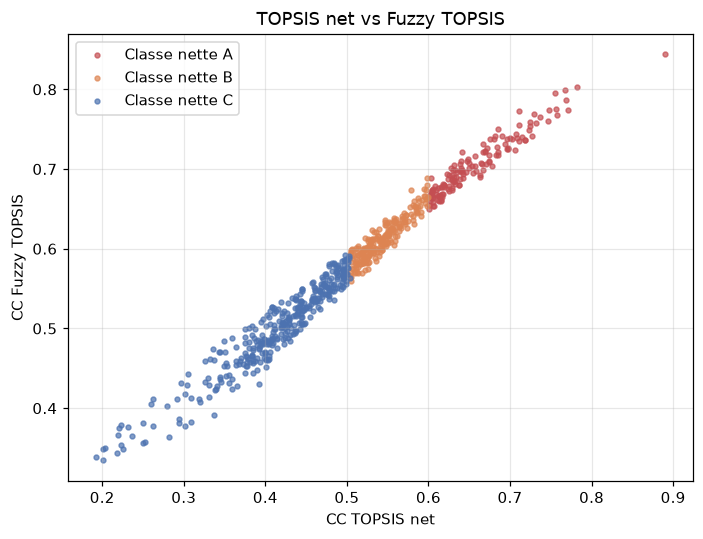

In [26]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for k in labels:
    g = fz[fz["Classe"] == k]
    ax.scatter(g["Score TOPSIS"], g["CC flou"], s=10, color=colors[k], label=f"Classe nette {k}", alpha=0.7)
ax.set_xlabel("CC TOPSIS net"); ax.set_ylabel("CC Fuzzy TOPSIS"); ax.set_title("TOPSIS net vs Fuzzy TOPSIS"); ax.legend()
plt.tight_layout(); plt.show()

### c) Classes ABC floues

Au lieu de seuils nets, on définit trois ensembles flous sur le rang centile $p_i = \text{rang}_i / n$ (0 = meilleur article), avec une **zone de transition** de largeur $\pm\delta$ (ici $\delta = 5$ points de centile) autour des frontières 20 % et 50 % :

- $\mu_A(p) = 1$ si $p \le 0{,}15$ ; décroît linéairement jusqu'à 0 en $p = 0{,}25$ ;
- $\mu_B(p)$ trapézoïdale : monte de 0,15 à 0,25, vaut 1 jusqu'à 0,45, redescend à 0 en 0,55 ;
- $\mu_C(p)$ monte de 0,45 à 0,55, puis vaut 1.

On a $\mu_A + \mu_B + \mu_C = 1$ (partition floue de Ruspini). Un article de rang 140 n'est plus « A » ou « B » mais, par exemple, A à 50 % / B à 50 % : le gestionnaire peut lui appliquer une politique intermédiaire ou le placer sous revue prioritaire.

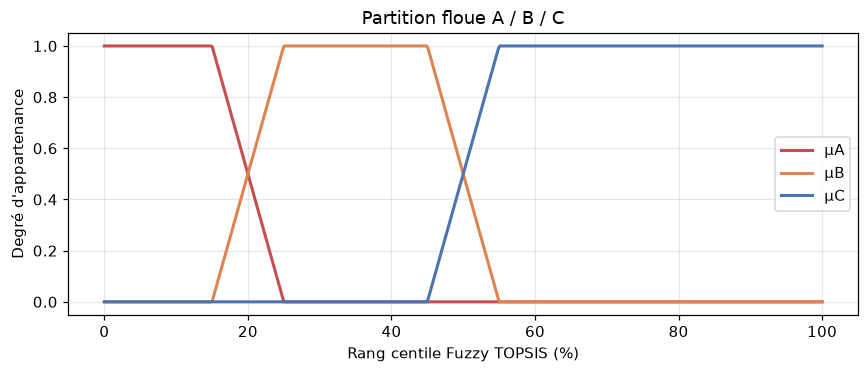

{'Net': 560, 'Frontière': 140}


,Risk,Demand fluctuation,Average stock,Daily usage,Unit cost,Lead time,Consignment stock,Unit size,CC flou,Rang flou,µA,µB,µC,Classe floue
331,Normal,Increasing,195.85,0.84,8.1765,18,No,Medium,0.6646,136,0.5643,0.4357,0.0000,A
93,High,Ending,130.98,1.92,5.8828,30,Yes,Medium,0.6641,137,0.5500,0.4500,0.0000,A
600,Normal,Increasing,64.31,1.97,8.2940,25,Yes,Medium,0.6641,138,0.5357,0.4643,0.0000,A
599,Normal,Ending,42.64,3.24,4.0426,26,No,Large,0.6636,139,0.5214,0.4786,0.0000,A
284,High,Ending,162.53,0.41,8.8118,19,No,Medium,0.6633,140,0.5071,0.4929,0.0000,A
42,Normal,Ending,66.38,2.41,5.8546,30,No,Medium,0.6624,141,0.4929,0.5071,0.0000,B
484,Normal,Unknown,193.24,2.30,6.4178,18,No,Medium,0.6609,142,0.4786,0.5214,0.0000,B
64,High,Unknown,72.85,2.41,8.3904,18,Yes,Medium,0.6607,143,0.4643,0.5357,0.0000,B
203,Low,Unknown,37.07,4.30,7.2526,18,Yes,Large,0.6606,144,0.4500,0.5500,0.0000,B
323,Normal,Stable,166.27,3.31,7.5848,8,No,Medium,0.6604,145,0.4357,0.5643,0.0000,B


In [27]:
DELTA = 0.05
def ramp_down(p, a, b): return np.clip((b - p) / (b - a), 0, 1)
def memberships(p):
    mA = ramp_down(p, 0.20 - DELTA, 0.20 + DELTA)
    mC = 1 - ramp_down(p, 0.50 - DELTA, 0.50 + DELTA)
    return mA, 1 - mA - mC, mC

p = (fz["Rang flou"].values - 0.5) / n
fz["µA"], fz["µB"], fz["µC"] = memberships(p)
fz["Classe (max µ)"] = fz[["µA", "µB", "µC"]].values.argmax(1)
fz["Classe (max µ)"] = fz["Classe (max µ)"].map({0: "A", 1: "B", 2: "C"})
fz["Statut"] = np.where(fz[["µA", "µB", "µC"]].max(axis=1) < 1, "Frontière", "Net")

grid = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(8, 3.5))
for lab, m in zip(labels, memberships(grid)):
    ax.plot(grid * 100, m, color=colors[lab], lw=2, label=f"µ{lab}")
ax.set_xlabel("Rang centile Fuzzy TOPSIS (%)"); ax.set_ylabel("Degré d'appartenance")
ax.set_title("Partition floue A / B / C"); ax.legend(); plt.tight_layout(); plt.show()

print(fz["Statut"].value_counts().to_dict())
# Exemples d'articles autour des deux frontières (rangs 136-145 et 346-355)
cols_fz = list(df.columns) + ["CC flou", "Rang flou", "µA", "µB", "µC", "Classe floue"]
fz.loc[fz["Rang flou"].between(136, 145) | fz["Rang flou"].between(346, 355), cols_fz].sort_values("Rang flou")

In [28]:
# Les articles mal classés par le ML se trouvent-ils dans les zones floues ?
err_idx = X_test.index[best_models[best_name].predict(X_test) != y_test]
in_zone = (fz.loc[err_idx, "Score TOPSIS"].sub(seuil_A).abs().lt(0.02) |
           fz.loc[err_idx, "Score TOPSIS"].sub(seuil_B).abs().lt(0.02))
print(f"Erreurs du modèle « {best_name} » sur le test : {len(err_idx)}")
print(f"dont à moins de 0,02 d'un seuil ABC (net) : {in_zone.sum()} ({100 * in_zone.mean():.0f} %)")

fz.to_csv("inventory_data_classe_floue.csv", index_label="Article")
print("Export : inventory_data_classe_floue.csv")

Erreurs du modèle « MLP » sur le test : 13
dont à moins de 0,02 d'un seuil ABC (net) : 13 (100 %)
Export : inventory_data_classe_floue.csv


**Apports de l'approche floue**

- **Représentation de l'imprécision** : les termes linguistiques et les mesures sont manipulés comme des intervalles pondérés, la modalité *Unknown* étant traitée explicitement comme la plus incertaine.
- **Robustesse vérifiée** : la corrélation entre classement net et classement flou est très forte (Spearman ≈ 0,99) et environ 93 % des articles gardent leur classe. Les changements (≈ 7 %) concernent uniquement des **classes adjacentes**, donc des articles proches des seuils.
- **Décision graduée** : les degrés d'appartenance $\mu_A, \mu_B, \mu_C$ identifient les articles « frontières » qui méritent une revue experte plutôt qu'une affectation mécanique. Ces articles sont précisément ceux sur lesquels les modèles de ML se trompent (cf. cellule ci-dessus), ce qui relie les erreurs de classification à une ambiguïté réelle de la donnée plutôt qu'à une faiblesse des modèles.
- **Extensions possibles** : poids linguistiques fournis par plusieurs experts (agrégation floue de jugements), Fuzzy AHP pour dériver les poids de la Table 2, ou apprentissage des degrés $\mu$ par régression (ou fuzzy c-means) pour une classification floue automatique des nouveaux articles.

## Conclusion

L'ABC multi-attributs construit ici dépasse l'ABC mono-critère : il intègre la criticité, la dynamique de la demande, les contraintes d'approvisionnement, le coût et l'encombrement. TOPSIS fournit un score unique et interprétable, la règle de Pareto 20/30/50 appliquée au rang donne les classes, les meilleurs modèles d'apprentissage (MLP, SVM, régression logistique) reproduisent cette classification à environ 93–94 % sur le jeu de test pour l'automatiser, et l'extension floue rend la démarche robuste à l'imprécision des données et des frontières de classes.